# **Assignment 1:** Image Classification with MLP vs CNN

**Objective:** Train and compare MLP and CNN models on MNIST or CIFAR-10 using PyTorch.

**Tasks:**
* Load dataset via torchvision.datasets.
* Implement:
  * MLP with 2 hidden layers
  * CNN with 2 Conv layers + ReLU + MaxPool + FC

* Train and compare models on:
  * Accuracy
  * Number of parameters
  * Training time

* Plot training/validation loss and accuracy vs epochs.

**Deliverables:**
* Complete code (.ipynb / .py)
* Short comparison report (tables/plots)



In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import random

## CIFAR-10 dataset

In [20]:
train_data = torchvision.datasets.CIFAR10(root='./data',
                                          train=True,
                                          download=True,
                                          transform=transforms.ToTensor())

test_data = torchvision.datasets.CIFAR10(root='./data',
                                         train=False,
                                         download=True,
                                         transform=transforms.ToTensor())

train_loader = torch.utils.data.DataLoader(train_data, batch_size=500, shuffle=True)

test_loader = torch.utils.data.DataLoader(test_data, batch_size=5000, shuffle=False)

In [21]:
print(f"Size of train_data: {len(train_data)}")
print(f"Size of test_data: {len(test_data)}")
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

print(f"Total samples in train_loader (batches * batch_size): {len(train_loader) * train_loader.batch_size}")

Size of train_data: 50000
Size of test_data: 10000
Number of batches in train_loader: 100
Number of batches in test_loader: 2
Total samples in train_loader (batches * batch_size): 50000


Shape of the single image: torch.Size([3, 32, 32])
Label of the single image: 6


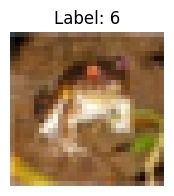

In [22]:
img_single, label_single = train_data[0]

print(f"Shape of the single image: {img_single.shape}")
print(f"Label of the single image: {label_single}")

# CIFAR-10 images are 3-channel. To display in color with matplotlib,
# we need to permute the dimensions from (C, H, W) to (H, W, C).
img_display_color = img_single.permute(1, 2, 0) # Change to (H, W, C)

plt.figure(figsize=(2, 2))
plt.imshow(img_display_color.numpy())
plt.title(f"Label: {label_single}")
plt.grid(False)
plt.axis('off')
plt.show()

In [23]:
print(train_data.classes)
print(train_data.class_to_idx)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


## MLP

In [24]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.linear1 = nn.Linear(3 * 32 * 32, 512)
        self.linear2 = nn.Linear(512, 256)
        self.linear3 = nn.Linear(256, 10)
    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten
        x = torch.relu(self.linear1(x))
        x = torch.relu(self.linear2(x))
        x = self.linear3(x)
        return x


In [25]:
def train_mlp(model, criterion, optimizer, train_loader, test_loader, epochs=10):
    loss_and_acc_mlp = {
        'training_loss': [],
        'training_accuracy': [],
        'test_loss': [],
        'test_accuracy': []
    }
    for epoch in range(epochs):
        # TRAINING
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        for x, y in train_loader:
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

        train_loss /= total
        train_acc = 100 * correct / total
        loss_and_acc_mlp['training_loss'].append(train_loss)
        loss_and_acc_mlp['training_accuracy'].append(train_acc)

        # TESTING
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in test_loader:
                outputs = model(x)
                loss = criterion(outputs, y)

                test_loss += loss.item() * x.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == y).sum().item()
                total += y.size(0)

        test_loss /= total
        test_acc = 100 * correct / total
        loss_and_acc_mlp['test_loss'].append(test_loss)
        loss_and_acc_mlp['test_accuracy'].append(test_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    return loss_and_acc_mlp

In [26]:
model_mlp = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=0.001)

import time

start_time = time.time()
training_results_mlp = train_mlp(model_mlp,criterion,optimizer,train_loader,test_loader,epochs=10)
end_time = time.time()

training_time_mlp = end_time - start_time
print(f"Training time for MLP: {training_time_mlp:.2f} seconds")

Epoch [1/10] Train Loss: 1.9304, Train Acc: 30.26% | Test Loss: 1.7746, Test Acc: 37.25%
Epoch [2/10] Train Loss: 1.7194, Train Acc: 38.76% | Test Loss: 1.7006, Test Acc: 39.69%
Epoch [3/10] Train Loss: 1.6316, Train Acc: 41.85% | Test Loss: 1.6054, Test Acc: 43.01%
Epoch [4/10] Train Loss: 1.5778, Train Acc: 44.07% | Test Loss: 1.5632, Test Acc: 44.72%
Epoch [5/10] Train Loss: 1.5194, Train Acc: 46.00% | Test Loss: 1.5056, Test Acc: 46.54%
Epoch [6/10] Train Loss: 1.4844, Train Acc: 47.10% | Test Loss: 1.4915, Test Acc: 46.85%
Epoch [7/10] Train Loss: 1.4520, Train Acc: 48.35% | Test Loss: 1.4559, Test Acc: 48.65%
Epoch [8/10] Train Loss: 1.4230, Train Acc: 49.40% | Test Loss: 1.4472, Test Acc: 48.93%
Epoch [9/10] Train Loss: 1.3901, Train Acc: 50.40% | Test Loss: 1.4180, Test Acc: 49.78%
Epoch [10/10] Train Loss: 1.3730, Train Acc: 51.11% | Test Loss: 1.4090, Test Acc: 50.48%
Training time for MLP: 125.36 seconds


* Calculate Number of Parameters for MLP

In [27]:
num_mlp_parameters = sum(p.numel() for p in model_mlp.parameters() if p.requires_grad)
print(f"Number of parameters in MLP: {num_mlp_parameters}")

Number of parameters in MLP: 1707274


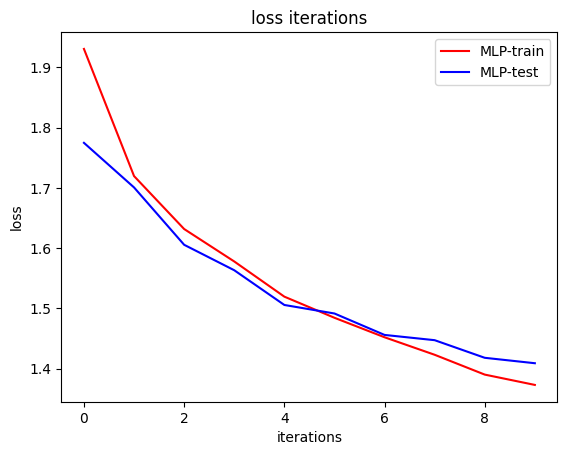

In [28]:
# Comparison of Loss
plt.plot(training_results_mlp['training_loss'], label='MLP-train', color="red" )
plt.plot(training_results_mlp['test_loss'], label='MLP-test', color="blue")
plt.xlabel('iterations')
plt.ylabel('loss')
plt.title('loss iterations')
plt.legend()

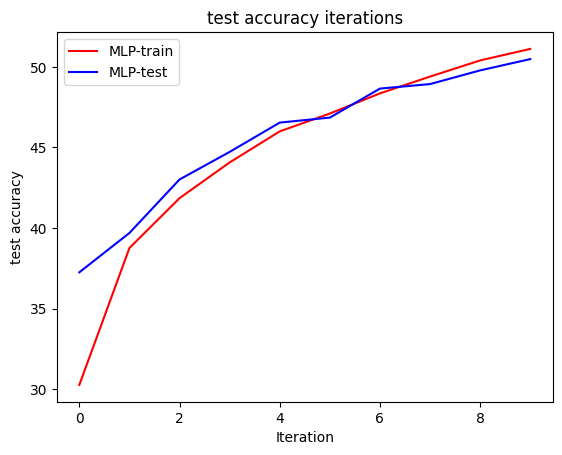

In [29]:
# Comparison of validation accuracy
plt.plot(training_results_mlp['training_accuracy'], label = 'MLP-train', color="red")
plt.plot(training_results_mlp['test_accuracy'], label = 'MLP-test', color="blue")
plt.ylabel('test accuracy')
plt.xlabel('Iteration')
plt.title('test accuracy iterations')
plt.legend()

## CNN

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)          # 32×16×16

        x = torch.relu(self.conv2(x))
        x = self.pool2(x)          # 64×8×8

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

In [13]:
def train_cnn(model, criterion, optimizer, train_loader, test_loader, epochs=10):
    loss_and_acc_cnn = {
        'training_loss': [],
        'training_accuracy': [],
        'test_loss': [],
        'test_accuracy': []
    }
    for epoch in range(epochs):

        # TRAINING
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        for x, y in train_loader:
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

        train_loss /= total
        train_acc = 100 * correct / total
        loss_and_acc_cnn['training_loss'].append(train_loss)
        loss_and_acc_cnn['training_accuracy'].append(train_acc)

        # TESTING
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in test_loader:
                outputs = model(x)
                loss = criterion(outputs, y)

                test_loss += loss.item() * x.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == y).sum().item()
                total += y.size(0)

        test_loss /= total
        test_acc = 100 * correct / total
        loss_and_acc_cnn['test_loss'].append(test_loss)
        loss_and_acc_cnn['test_accuracy'].append(test_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    return loss_and_acc_cnn

In [15]:
import time
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

start_time = time.time()
training_results_cnn = train_cnn(model,criterion,optimizer,train_loader,test_loader,epochs=10)
end_time = time.time()

training_time_cnn = end_time - start_time
print(f"Training time for CNN: {training_time_cnn:.2f} seconds")

Epoch [1/10] Train Loss: 1.7810, Train Acc: 36.92% | Test Loss: 1.5104, Test Acc: 47.03%
Epoch [2/10] Train Loss: 1.4264, Train Acc: 49.97% | Test Loss: 1.3298, Test Acc: 53.76%
Epoch [3/10] Train Loss: 1.2865, Train Acc: 55.16% | Test Loss: 1.2351, Test Acc: 56.64%
Epoch [4/10] Train Loss: 1.2068, Train Acc: 58.01% | Test Loss: 1.2118, Test Acc: 57.75%
Epoch [5/10] Train Loss: 1.1487, Train Acc: 60.01% | Test Loss: 1.1276, Test Acc: 60.11%
Epoch [6/10] Train Loss: 1.0986, Train Acc: 61.87% | Test Loss: 1.1035, Test Acc: 61.81%
Epoch [7/10] Train Loss: 1.0570, Train Acc: 63.33% | Test Loss: 1.0706, Test Acc: 63.09%
Epoch [8/10] Train Loss: 1.0217, Train Acc: 64.80% | Test Loss: 1.0529, Test Acc: 63.79%
Epoch [9/10] Train Loss: 0.9913, Train Acc: 65.86% | Test Loss: 1.0140, Test Acc: 64.79%
Epoch [10/10] Train Loss: 0.9591, Train Acc: 66.89% | Test Loss: 0.9943, Test Acc: 65.51%
Training time for CNN: 719.81 seconds


In [16]:
num_cnn_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of parameters in CNN: {num_cnn_parameters}")

Number of parameters in CNN: 60362


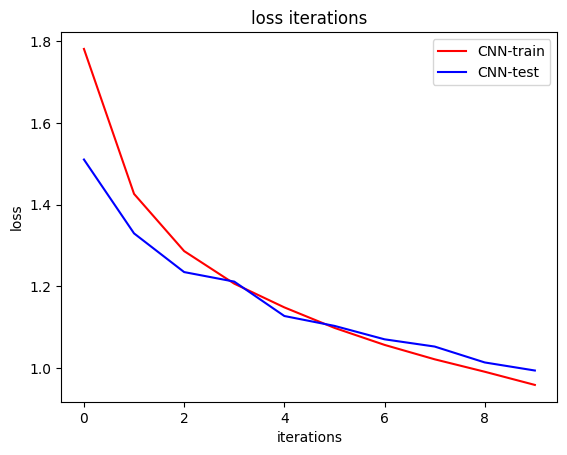

In [17]:
# Comparison of Loss
plt.plot(training_results_cnn['training_loss'], label='CNN-train', color="red" )
plt.plot(training_results_cnn['test_loss'], label='CNN-test', color="blue")
plt.xlabel('iterations')
plt.ylabel('loss')
plt.title('loss iterations')
plt.legend()

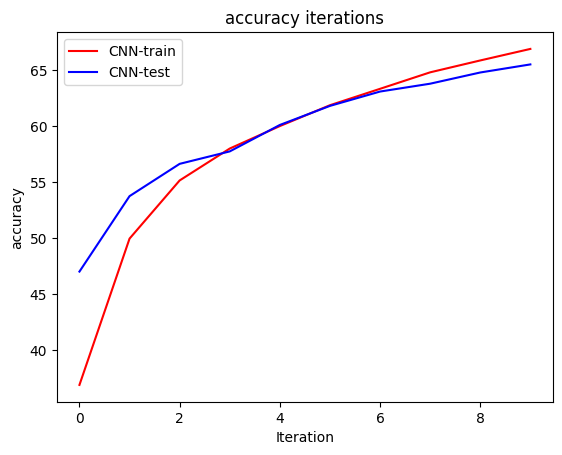

In [18]:
# Comparison of validation accuracy
plt.plot(training_results_cnn['training_accuracy'], label = 'CNN-train', color="red")
plt.plot(training_results_cnn['test_accuracy'], label = 'CNN-test', color="blue")
plt.ylabel('accuracy')
plt.xlabel('Iteration')
plt.title('accuracy iterations')
plt.legend()